In [1]:
import re
import os
from pathlib import Path
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import SimpleITK as sitk

# Functions

In [3]:
def parse_mask_filename(filename: str):
    """
    Extract region, center, and year from filenames like:
    - AB_1ABC118_mask.nii.gz
    - brain_1BA345_mask.nii.gz

    Rules:
    - Extract the part between the first and second underscore.
    - center = last letter of that segment
    - region = all letters before the center
    - year = 2023 if region is 'B' or 'P', otherwise 2025
    """
    # Get substring between first and second underscore
    match = re.search(r'^[^_]+_([^_]+)_', filename)
    if not match:
        raise ValueError(f"Filename format not recognized: {filename}")

    middle = match.group(1)

    # Extract letters only
    letters = re.findall(r'[A-Za-z]', middle)
    if not letters:
        raise ValueError(f"No letters found in middle segment of {filename}")

    center = letters[-1]
    region = ''.join(letters[:-1])

    # Year rule
    year = "2023" if region in ("B", "P") else "2025"

    center_year = center + "_" + year

    return region, center_year

def find_mask_sizes(mask_paths):
    rows = []
    for path in tqdm(mask_paths):
        volume_id = path.split("/")[-1]
        region, center_year = parse_mask_filename(volume_id)
        img = sitk.ReadImage(str(path))
        arr = sitk.GetArrayFromImage(img).astype(np.uint8)  # [z, y, x]
        
        Z, H, W = arr.shape
        
        for z in range(Z):
            slice_mask = arr[z] > 0
            if not slice_mask.any():
                continue  # skip empty slices
            
            ys, xs = np.where(slice_mask)
            y_min, y_max = ys.min(), ys.max()
            x_min, x_max = xs.min(), xs.max()
            
            bbox_height = y_max - y_min + 1
            bbox_width  = x_max - x_min + 1
            mask_area   = slice_mask.sum()
            
            rows.append({
                "volume_id": volume_id,
                "region": region,
                "center_year": center_year,
                "slice_idx": z,
                "orig_height": H,
                "orig_width": W,
                "y_min": y_min,
                "y_max": y_max,
                "x_min": x_min,
                "x_max": x_max,
                "bbox_height": bbox_height,
                "bbox_width": bbox_width,
                "mask_area": int(mask_area),
            })

    # Save metadata for later analysis
    df = pd.DataFrame(rows)

    return df

def plot_bbox_heatmap(df, regions=None, bins=50):
    """
    Plot a 2D histogram (heatmap) of bbox_height vs bbox_width,
    forcing both axes to use the same maximum value.
    """

    # Normalize regions argument
    if regions is not None:
        if isinstance(regions, str):
            regions = [regions]
        df = df[df['region'].isin(regions)]

    # Compute shared max for both axes
    max_val = max(df['bbox_width'].max(), df['bbox_height'].max())

    plt.figure(figsize=(7, 6))

    plt.hist2d(
        df['bbox_width'],
        df['bbox_height'],
        bins=bins,
        range=[[0, max_val], [0, max_val]],   # enforce square axes
        cmap='viridis'
    )

    plt.colorbar(label="Count")
    plt.xlabel("Mask BB Width per Slice [in pixels]")
    plt.ylabel("Mask BB Height per Slice [in pixels]")

    title = "Bounding Box of Masks per Axial Slice"
    if regions is not None:
        title += f" (regions={regions})"
    plt.title(title)

    # Ensure equal aspect ratio visually
    plt.gca().set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()

def cropping_loss_share(df, regions, min_size):
    """
    df       : DataFrame with at least columns ['region', 'bbox_height', 'bbox_width'] (and optionally 'max_bbox')
    regions  : list-like of region names to filter on
    min_size : threshold for max_bbox (inclusive)
    
    Returns: float in [0, 1] = share of rows (for given regions)
             whose max_bbox >= min_size.
             Returns np.nan if there are no rows for those regions.
    """
    # restrict to selected regions
    sub = df[df['region'].isin(regions)].copy()
    
    if sub.empty:
        return np.nan  # or 0.0, depending on what you prefer

    # ensure max_bbox exists (recompute if necessary)
    if 'max_bbox' not in sub.columns:
        sub['max_bbox'] = sub[['bbox_height', 'bbox_width']].max(axis=1)

    # boolean mask where max_bbox >= min_size
    share = (sub['max_bbox'] >= min_size).mean()
    return float(share)

# Data Loading

In [6]:
# find filenames per data split (to work in 1initNifti)
datadir = "/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/1initNifti"
outdir = "/home/user/fthuer/fullbody-sCT/analysis"
os.chdir(outdir)
split = pd.read_csv("../splits_manifest.csv")
split["folder"] = split["example_path"].str.split("/").str[-1]
split["filename"] = split["folder"] + "_mask.nii.gz"
# # for old masks
# split["path"] = split["folder"] + "/masks/" + split["filename"]
# for new masks
split["path"] = split["folder"] + "/new_masks/" + split["filename"].str.replace("mask", "mask_from_CT_treshold")
all_files = split["path"].tolist()


# Calculate mask sizes
os.chdir(datadir)
mask_sizes = find_mask_sizes(all_files)
os.chdir(outdir)
mask_sizes.to_csv("new_mask_dimensions.csv", index=False)
# # for old masks
# mask_sizes.to_csv("mask_dimensions.csv", index=False)

# Load pre-calculated mask sizes for analysis
os.chdir(outdir)
mask_sizes = pd.read_csv("new_mask_dimensions.csv")
# # for old masks
# mask_sizes = pd.read_csv("mask_dimensions.csv")

mask_sizes['max_bbox'] = mask_sizes[['bbox_height', 'bbox_width']].max(axis=1)

  0%|          | 0/938 [00:00<?, ?it/s]

100%|██████████| 938/938 [03:44<00:00,  4.19it/s]


# Analysis Share of Masks with Cropping Losses

In [7]:
regions = ["AB", "TH", "P"]
print(regions)
for i in range(7):
    scale_factor = round(0.8 + i/5, 1)
    size_px = round(scale_factor * 256)
    loss = cropping_loss_share(mask_sizes, regions=regions, min_size=size_px)
    print(f"Factor {scale_factor}: Loss of mask area in {round(loss*100, 2)}% of slices")

['AB', 'TH', 'P']
Factor 0.8: Loss of mask area in 98.58% of slices
Factor 1.0: Loss of mask area in 97.82% of slices
Factor 1.2: Loss of mask area in 90.73% of slices
Factor 1.4: Loss of mask area in 60.47% of slices
Factor 1.6: Loss of mask area in 18.57% of slices
Factor 1.8: Loss of mask area in 3.84% of slices
Factor 2.0: Loss of mask area in 0.66% of slices


In [8]:
regions = ["B", "HN"]
print(regions)
for i in range(7):
    scale_factor = round(0.8 + i/5, 1)
    size_px = round(scale_factor * 256)
    loss = cropping_loss_share(mask_sizes, regions=regions, min_size=size_px)
    print(f"Factor {scale_factor}: Loss of mask area in {round(loss*100, 2)}% of slices")

['B', 'HN']
Factor 0.8: Loss of mask area in 16.25% of slices
Factor 1.0: Loss of mask area in 4.77% of slices
Factor 1.2: Loss of mask area in 4.35% of slices
Factor 1.4: Loss of mask area in 4.06% of slices
Factor 1.6: Loss of mask area in 3.31% of slices
Factor 1.8: Loss of mask area in 1.38% of slices
Factor 2.0: Loss of mask area in 0.3% of slices


# Plotting of Bounding Box sizes

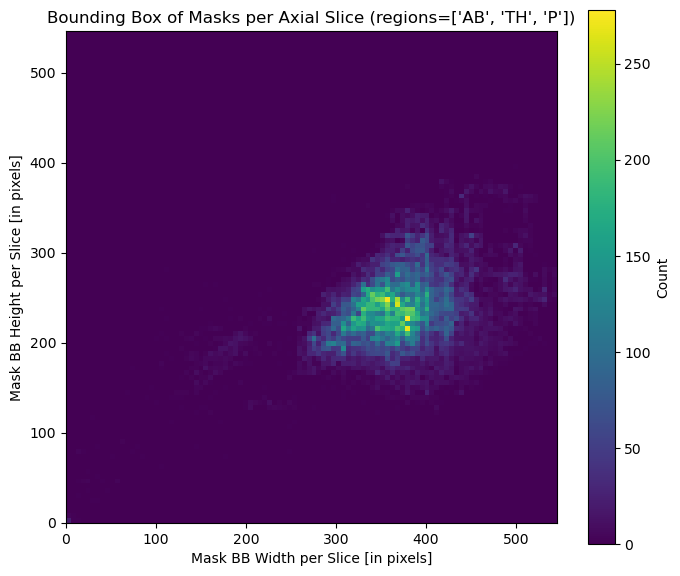

In [9]:
plot_bbox_heatmap(mask_sizes, regions=["AB", "TH", "P"], bins=100)

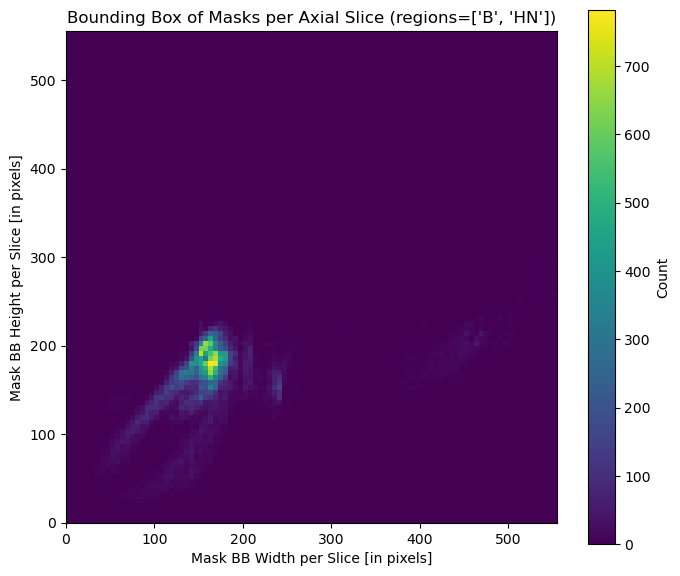

In [10]:
plot_bbox_heatmap(mask_sizes, regions=["B", "HN"], bins=100)

In [11]:
df_by_volume = (
    mask_sizes
    .groupby(['volume_id', 'region', 'center_year', 'orig_height', 'orig_width'])
    [['bbox_height', 'bbox_width', 'mask_area']]
    .agg(['median', 'max'])
)

df_by_volume.columns = ['_'.join(col) for col in df_by_volume.columns]
df_by_volume = df_by_volume.reset_index()
df_by_volume.sample(10)

,volume_id,region,center_year,orig_height,orig_width,bbox_height_median,bbox_height_max,bbox_width_median,bbox_width_max,mask_area_median,mask_area_max
532,TH_1THB095_mask_from_CT_treshold.nii.gz,TH,B_2025,440,443,279.0,296,364.0,402,85640.0,87981
255,HN_1HNA129_mask_from_CT_treshold.nii.gz,HN,A_2025,320,244,175.0,218,163.0,209,23152.0,39851
929,pelvis_1PC084_mask_from_CT_treshold.nii.gz,P,C_2023,304,432,254.0,261,372.0,383,78018.0,82722
147,AB_1ABB161_mask_from_CT_treshold.nii.gz,AB,B_2025,392,400,255.0,259,337.5,354,72537.0,74639
476,TH_1THA280_mask_from_CT_treshold.nii.gz,TH,A_2025,458,462,239.5,260,425.0,426,85226.5,87828
596,brain_1BA111_mask_from_CT_treshold.nii.gz,B,A_2023,256,238,161.0,216,164.0,193,21286.0,30070
680,brain_1BB100_mask_from_CT_treshold.nii.gz,B,B_2023,236,219,173.5,201,166.0,180,23874.5,26132
787,pelvis_1PA052_mask_from_CT_treshold.nii.gz,P,A_2023,361,484,275.0,319,401.0,446,92447.0,127616
558,TH_1THB199_mask_from_CT_treshold.nii.gz,TH,B_2025,459,458,202.0,215,289.5,374,47363.5,53195
380,HN_1HND084_mask_from_CT_treshold.nii.gz,HN,D_2025,302,276,155.0,186,150.0,236,21211.0,32020
